In [1]:
import re

In [2]:
import json

In [3]:
import pickle

In [4]:
import tqdm

In [5]:
from dotenv import load_dotenv

In [6]:
load_dotenv()

True

In [7]:
import numpy as np

In [8]:
import pandas as pd

In [9]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

In [11]:
from transformers import AutoProcessor, AutoModelForCausalLM

In [12]:
MODEL_ID = "google/gemma-4-E2B-it"

In [13]:
processor = AutoProcessor.from_pretrained(MODEL_ID, temperature=0.1)

In [14]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

In [15]:
df = pd.read_excel("data.xlsx", header=0)

In [16]:
df.head()

,title_rus,title_eng,goals,tasks,annotation,description,expectations,product_result,result_criterias,social_effect,commercial_effect
0,Исследование приоритетов и механизмов реализац...,Study of Priorities and Mechanisms for Impleme...,Целью проекта является эмпирическая проверка г...,1) Анализ повестки международных доноров\n2) А...,Работа международных фондов (доноров) должна п...,"Согласно определению международных фондов, про...",Аналитический отчет по избранным странам.\n\nС...,NaN,NaN,NaN,NaN
1,Антрополе - научно-популярный видео-подкаст о ...,Anthropole is a Popular Science Video Podcast ...,Выпустить и популяризовать 27 видео-подкастов ...,Снять и смонтировать подкасты;\nРазработать ст...,"\tАнтрополе - научно-популярный проект, в рамк...","Социальное знание близко и интересно обществу,...","Студенты получат опыт монтажа, продвижения и к...",Регулярный видео-подкаст (+экспедиционные филь...,Опубликованы 27 видео-подкастов о необычных со...,Популяризация социального знания должна привес...,Планируется в течение года выйти на окупаемост...
2,"Разработка, создание и ведение сайта, посвящен...","Design, Development and Implementation of a We...","Для того, чтобы получить более полное представ...",Подготовка технического задания для разработчи...,Художественное образование и творчество художн...,Тема обучения арабских художников в художестве...,"Навыки создания сайта (полный цикл, от подгото...","Создание сайта, посвященного истории арабских ...",Выполнение заданий руководителя проекта,Укрепление международных связей с художниками ...,NaN
3,Перевод с английского языка коллективной моног...,Translation from English of the collective mon...,Результатом проекта станет качественный перево...,Результатом проекта станет качественный перево...,"Коллективная монография, авторы которой являют...","Коллективная монография, авторы которой являют...",Участники проекта приобретут новые знания в об...,Результатом проекта станет качественный перево...,Критериями достижения результата будет возможн...,NaN,NaN
4,Сеть военно-политических союзов в Евразии: баз...,Network of Military in Eurasia: a Database,Целью проекта является создание базы данных со...,1.\tОпределение методики включения союзов в ба...,Проект посвящен изучению сети военно-политичес...,Проект посвящен анализу истории существования ...,1.\tОбучение навыкам сбора и анализа данных 2....,База данных союзов 1815-2024 в Евразии.,Создание базы данных как минимум тысячи диадны...,NaN,NaN


In [17]:
df = df.fillna("")

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
with open("artificial_profiles.json", "r") as f:
    profiles = json.load(f)

In [20]:
profiles.update({
'monetary_policy_researcher': 'A user, which is interesed in macroeconimcs in general and monetary police studies in particular',
'computer_vision_researcher': 'A user, which is interested in machine learning and computer vision in particular'
})

In [21]:
profiles

{'digital_humanities_researcher': 'A user interested in the intersection of digital humanities, historical text analysis, and potentially computational linguistics or data science applied to humanities subjects. They value deep textual analysis and digital preservation methods.',
 'speech_ai_developer': 'A user focused on Artificial Intelligence, specifically in Speech Recognition and Natural Language Processing (NLP), with an interest in developing and implementing Speech AI systems.',
 'academic_researcher_hse_gcii': 'A user focused on academic research, potentially in education technology or specific academic fields (like HSE GCII), with a strong interest in structured research methodologies and potentially advanced topics like cognitive science or educational data.',
 'crm_travel_tech_analyst': 'A user interested in Business Intelligence (CRM), Travel Technology, and B2B strategies, likely focusing on market analysis, customer relationship management, and tech integration in the tr

In [22]:
results = {}

In [23]:
for profile in profiles:
    SYSTEM_PROMPT = f"""
    You are a {profile}.
    {profiles[profile]}
    Evaluate, how much you would like proposed student project based on its title in russian. Rate it on a scale [None, 1, 2, 3, 4, 5], where the higher the better.
    If proposed project title does not fit your interests, just return None.
    Return stricly JSON.
    For example.
    """
    SYSTEM_PROMPT += """
    ```json
    {'score': 4}
    ```
    ```json
    {'score': None}
    ```
    """

    messages = []
    scores = {}
    for row in df.sample(frac=0.1).iterrows():
        messages.append(
            (
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": row[1]["title_rus"]}
            )
        )
    for message in tqdm.tqdm(messages):
        text = processor.apply_chat_template(
            message, 
            tokenize=False, 
            add_generation_prompt=True, 
            enable_thinking=False
        )
        
        inputs = processor(text=text, return_tensors="pt").to(model.device)
        input_len = inputs["input_ids"].shape[-1]
        
        outputs = model.generate(**inputs, max_new_tokens=1024)
        response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

        try:
            json_match = re.search(r'```json\s*(.*?)\s*```', response, re.DOTALL)
            if json_match:
                json_str = json_match.group(1)
            else:
                json_str = response
            answer = json.loads(json_str)
        except Exception:
            answer = {"score": 'None'}
        
        score = answer.get("score", 'None')
        try:
            score = int(score)
        except Exception:
            score = None

        scores[message[1]["content"]] = score
    nans = [1 if x else 0 for x in list(scores.values())]
    if nans:
        nans_mean = np.round(np.mean(nans), 4)
    else:
        nans_mean = np.nan
    values = [x for x in list(scores.values()) if x]
    if values:
        values_median = np.median(values)
    else:
        values_median = np.nan
    print(f"{profile}: {nans_mean}, {values_median}")
    results[profile] = scores

100%|██████████| 125/125 [03:50<00:00,  1.85s/it]


digital_humanities_researcher: 0.696, 2.0


100%|██████████| 125/125 [03:39<00:00,  1.75s/it]


speech_ai_developer: 0.3065, 2.0


100%|██████████| 125/125 [03:46<00:00,  1.81s/it]


...

general_linguistics_enthusiast: 0.592, 2.0


100%|██████████| 125/125 [03:26<00:00,  1.65s/it]


monetary_policy_researcher: 0.304, 2.0


100%|██████████| 125/125 [03:20<00:00,  1.61s/it]

computer_vision_researcher: 0.368, 3.0


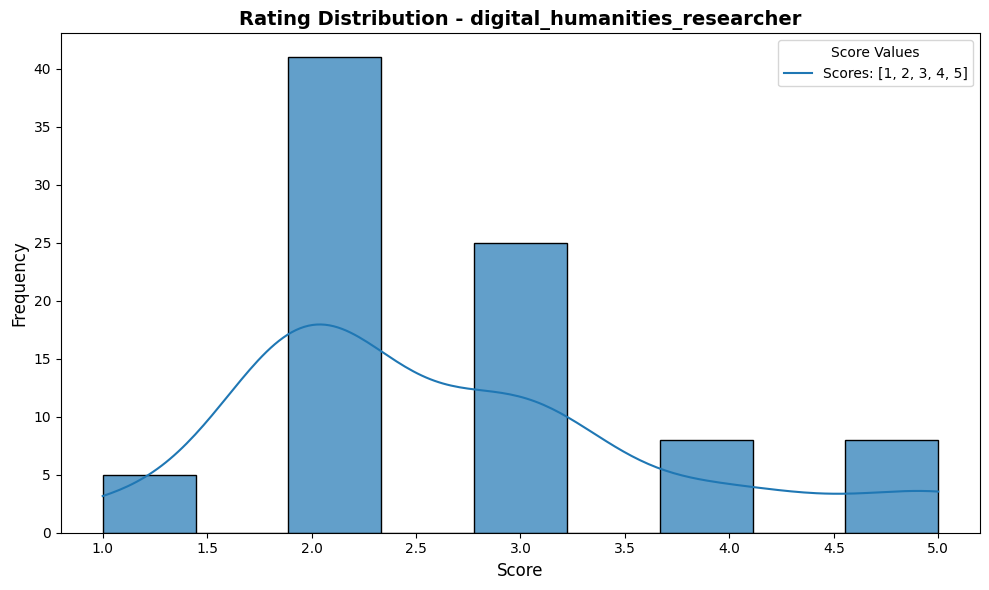

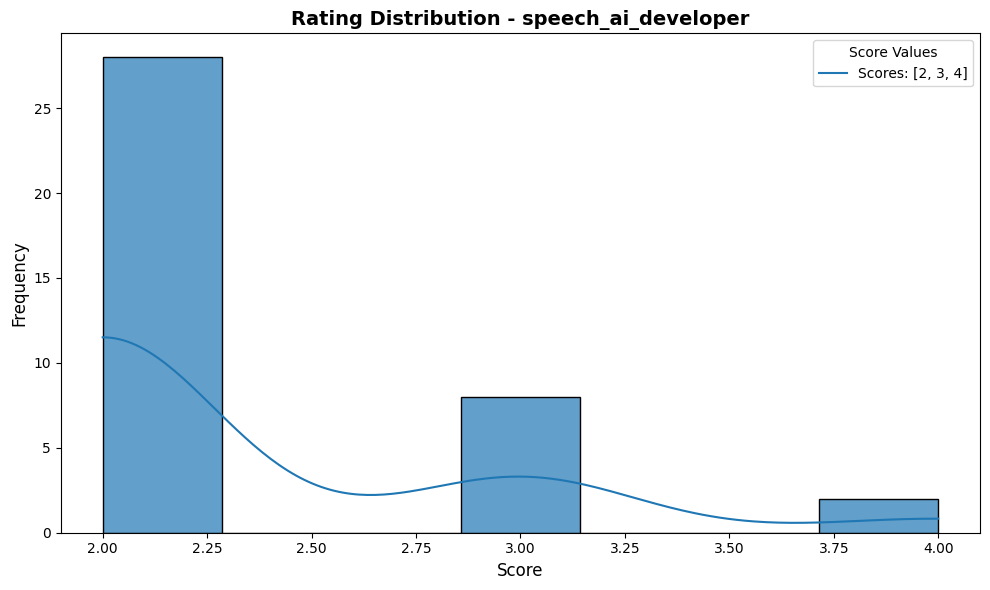

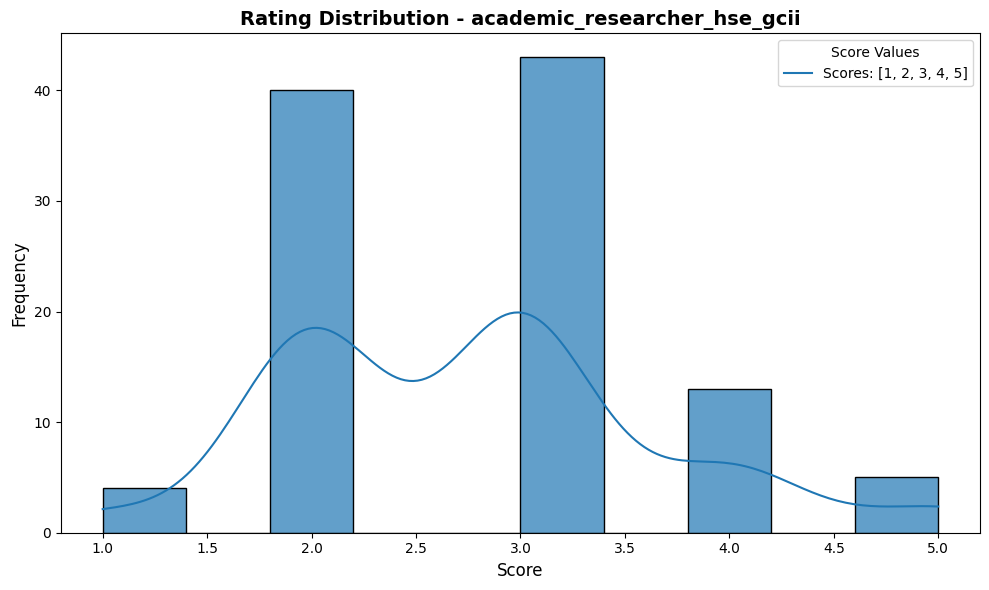

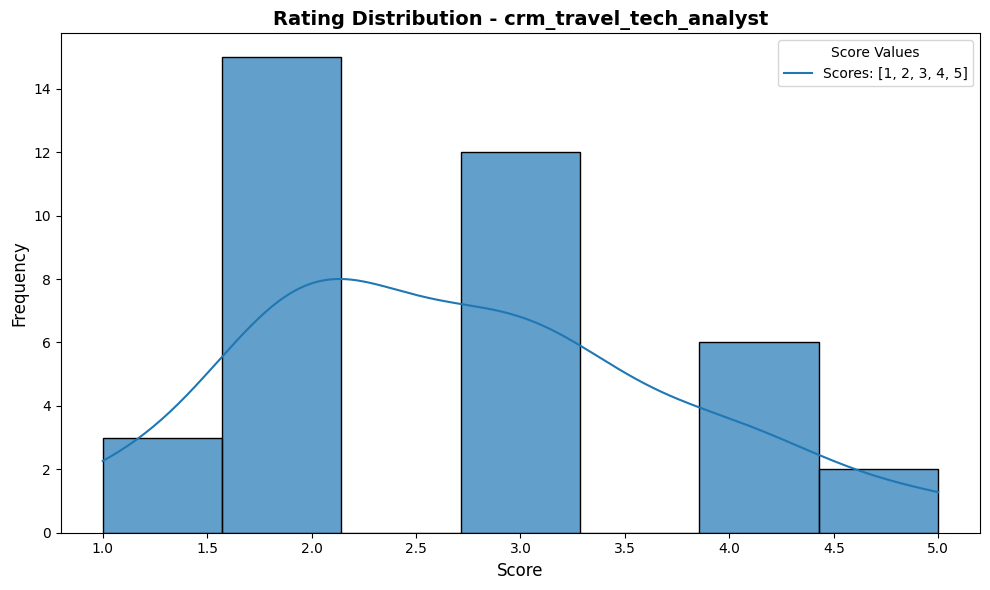

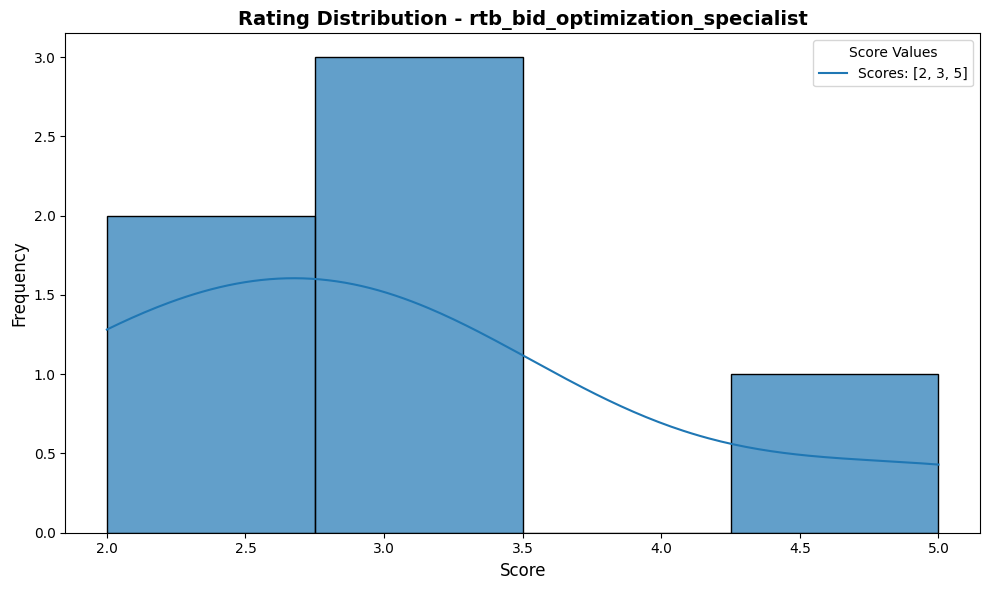

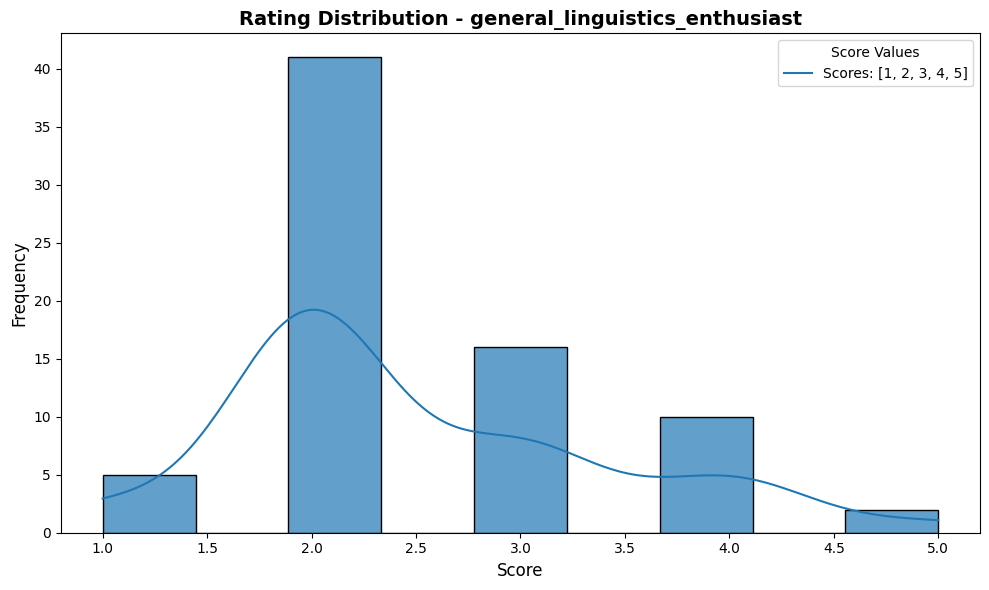

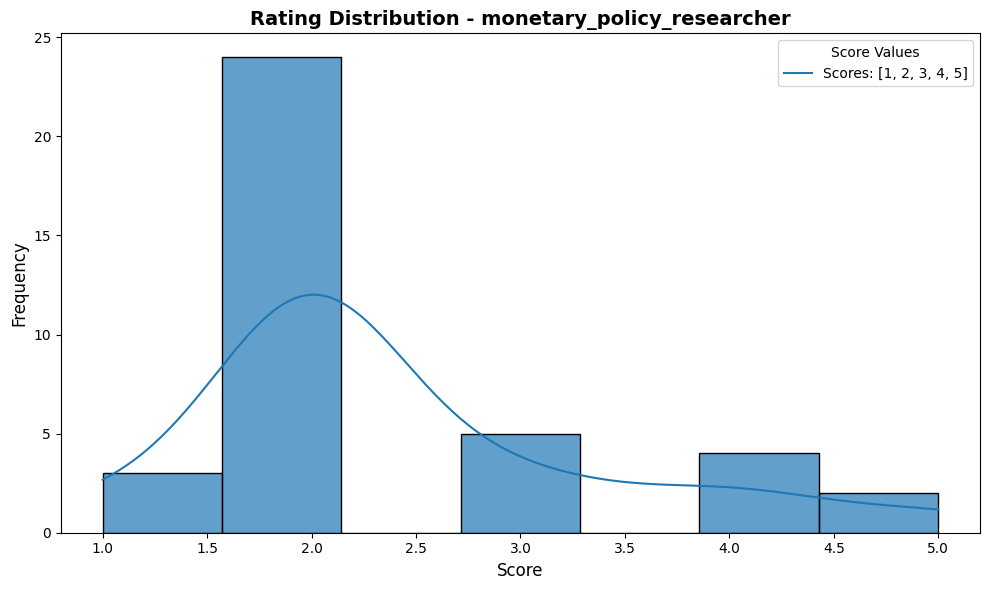

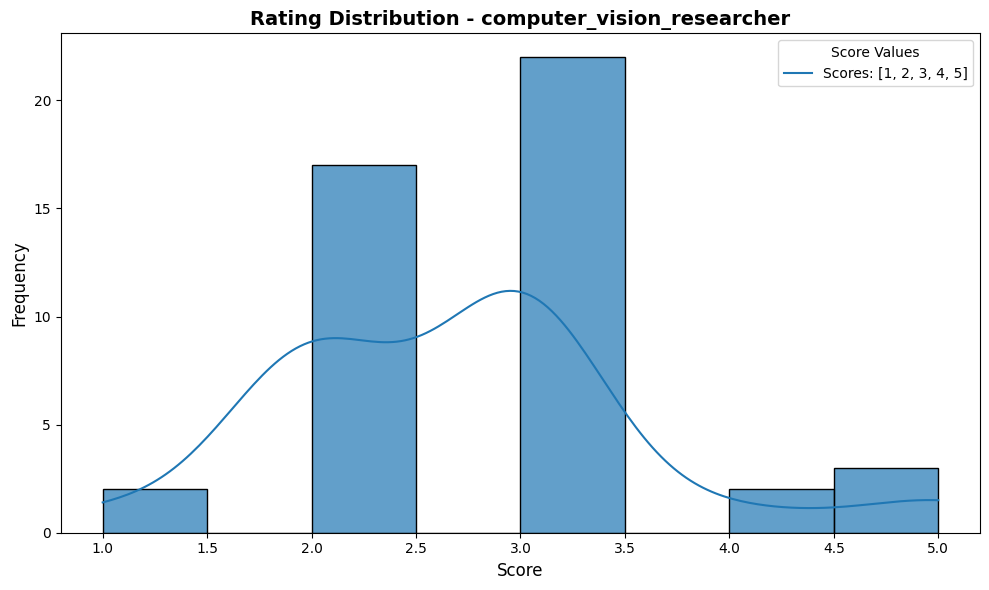

In [24]:
for researcher in results:
    fig, ax = plt.subplots(figsize=(10, 6))
    scores_list = list(results[researcher].values())
    
    sns.histplot(scores_list, ax=ax, alpha=0.7, kde=True)
    
    ax.set_title(f'Rating Distribution - {researcher}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Score', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    
    unique_scores = sorted(set([x for x in scores_list if x is not None]))
    if unique_scores:
        ax.legend([f'Scores: {unique_scores}'], title='Score Values', loc='best')
    
    plt.tight_layout()
    plt.show()

In [25]:
for researcher in results:
    data = [x for x in results[researcher].items() if x[1]]
    if data:
        for topic, score in sorted(data, key=lambda x: x[1], reverse=True)[:10]:
            print(f"{researcher}, {topic}, {score}")
    print()

digital_humanities_researcher, Концепция "памяти жанра" М. М. Бахтина: теоретическая проблема и современная литературная практика (на материале романа Дж. Франзена "Поправки")), 5
digital_humanities_researcher, Поэтика Ильи Кормильцева на материале сборника "Скованные одной цепью" (1990), 5
digital_humanities_researcher, Везувианская зона как метамузей Древнего Рима: апробация редизайна курса и подготовки учебного пособия, 5
digital_humanities_researcher, Религиозный ландшафт города: пост-секулярная история религиозных общин Санкт-Петербурга, 5
digital_humanities_researcher, Университетские кодексы и их влияние на этику поведения, 5
digital_humanities_researcher, Создание электронного хранилища-библиотеки, 5
digital_humanities_researcher,  «Поэтика Василия Филиппова в свете концепции искусства аутсайдеров», 5
digital_humanities_researcher, Тайна как эстетическая категория в научно-фантастической повести братьев Стругацких "Пикник на обочине", 5
digital_humanities_researcher, Анализ, оп

In [26]:
with open("artificial_profiles_scores.pkl", "wb") as f:
    pickle.dump(results, f)